#### CARGA

In [1]:
import random
import string 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def generate_id() -> str:
    return "".join(random.choices(string.ascii_lowercase,k=8))

In [3]:
df_og = pd.read_csv('../data/processed/dinn_dataset.csv')

df = df_og.copy() #criando cópia do dataframe original

countries = ['Argentina','Colombia','Uruguay','Peru','Panama']
df = df.copy().query('country in @countries')
df['id'] = [generate_id() for c in range(len(df))]
df['unique_id'] = df['id']+df['country'].str.slice(0,2).str.upper()+df['year'].astype(str).str.slice(2)
df.drop(columns='id',inplace=True,)
df.info()

C:\Users\Andrew\AppData\Local\Temp\ipykernel_3612\2860674860.py:1: DtypeWarning: Columns (4,63) have mixed types. Specify dtype option on import or set low_memory=False.
  df_og = pd.read_csv('../data/processed/dinn_dataset.csv')


<class 'pandas.core.frame.DataFrame'>
Int64Index: 84448 entries, 0 to 119899
Data columns (total 66 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   country         84448 non-null  object 
 1   fucode          84448 non-null  float64
 2   exp_f           84448 non-null  float64
 3   year            84448 non-null  int64  
 4   isic3_1d        58747 non-null  object 
 5   isic3_2d        74307 non-null  float64
 6   sales_us_Y1     30360 non-null  float64
 7   sales_us_Y2     58096 non-null  float64
 8   sales_us_Y3     18973 non-null  float64
 9   export_us_Y1    22886 non-null  float64
 10  export_us_Y2    50621 non-null  float64
 11  export_us_Y3    10796 non-null  float64
 12  dexport         64460 non-null  float64
 13  empl_Y1         79307 non-null  float64
 14  empl_Y2         76733 non-null  float64
 15  empl_Y3         19089 non-null  float64
 16  phd_Y1          64593 non-null  float64
 17  phd_Y2          64368 non-null

In [4]:
df.head()

,country,fucode,exp_f,year,isic3_1d,isic3_2d,sales_us_Y1,sales_us_Y2,sales_us_Y3,export_us_Y1,...,dIPexp,dtrainexp,dIDexp,dmktexp,dongoingia,dabandia,innpd_scp,innpc_scp,dinn,unique_id
0,Argentina,32100384.0,3.236364,2013,Manufacturing,29.0,3172378.50,3443577.00,4585487.50,NaN,...,0.0,1,0.0,NaN,NaN,NaN,Firm,Country,1,qajhxxikAR13
1,Argentina,32100464.0,3.000000,2013,Manufacturing,21.0,3792378.30,4603159.50,5075659.50,NaN,...,1.0,1,1.0,NaN,NaN,NaN,Firm,Firm,1,xgxhfvltAR13
2,Argentina,32100794.0,5.701755,2013,Manufacturing,30.0,1031113.40,1348710.50,908472.06,NaN,...,0.0,0,0.0,NaN,NaN,NaN,Firm,Firm,1,rxlkxiwtAR13
3,Argentina,32100882.0,2.574074,2013,Manufacturing,33.0,1552950.90,1344115.30,764074.50,NaN,...,0.0,0,0.0,NaN,NaN,NaN,NaN,NaN,0,phzpxbyfAR13
4,Argentina,32100965.0,4.586207,2013,Manufacturing,34.0,543469.88,625183.19,587260.00,NaN,...,0.0,0,0.0,NaN,NaN,NaN,Country,Country,1,scjyznwsAR13


In [5]:
df['isic3_1d'].value_counts(normalize=True)

Manufacturing                                  0.732718
Wholesale and retail trade                     0.093996
Transport, storage, and communications         0.057024
Hotels and restaurants                         0.033040
Health and social work                         0.030402
Real state, renting and business activities    0.020937
social and personal services                   0.011507
Eletricity, gas and water supply               0.009549
Education                                      0.009192
Financial Intermediation                       0.001072
Construction                                   0.000392
Mining and quarrying                           0.000170
Name: isic3_1d, dtype: float64

In [6]:
all_years = df.loc[((df.sales_us_Y1.notnull())  &   (df.sales_us_Y2.notnull())  &   (df.sales_us_Y3.notnull()))]
only_yearone = df.loc[((df.sales_us_Y1.notnull())  &   (df.sales_us_Y2.isnull())  &   (df.sales_us_Y3.isnull()))]

In [7]:
df.export_us_Y1.describe()

count    2.288600e+04
mean     2.256352e+06
std      1.957120e+07
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      7.790580e+08
Name: export_us_Y1, dtype: float64

In [8]:
df.loc[(df.sales_us_Y1.notnull())]

,country,fucode,exp_f,year,isic3_1d,isic3_2d,sales_us_Y1,sales_us_Y2,sales_us_Y3,export_us_Y1,...,dIPexp,dtrainexp,dIDexp,dmktexp,dongoingia,dabandia,innpd_scp,innpc_scp,dinn,unique_id
0,Argentina,32100384.0,3.236364,2013,Manufacturing,29.0,3172378.50,3443577.00,4585487.50,NaN,...,0.0,1,0.0,NaN,NaN,NaN,Firm,Country,1,qajhxxikAR13
1,Argentina,32100464.0,3.000000,2013,Manufacturing,21.0,3792378.30,4603159.50,5075659.50,NaN,...,1.0,1,1.0,NaN,NaN,NaN,Firm,Firm,1,xgxhfvltAR13
2,Argentina,32100794.0,5.701755,2013,Manufacturing,30.0,1031113.40,1348710.50,908472.06,NaN,...,0.0,0,0.0,NaN,NaN,NaN,Firm,Firm,1,rxlkxiwtAR13
3,Argentina,32100882.0,2.574074,2013,Manufacturing,33.0,1552950.90,1344115.30,764074.50,NaN,...,0.0,0,0.0,NaN,NaN,NaN,NaN,NaN,0,phzpxbyfAR13
4,Argentina,32100965.0,4.586207,2013,Manufacturing,34.0,543469.88,625183.19,587260.00,NaN,...,0.0,0,0.0,NaN,NaN,NaN,Country,Country,1,scjyznwsAR13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119895,Uruguay,85811326.0,2.664913,2016,NaN,85.0,514188.16,675846.94,826708.00,0.0,...,0.0,0,0.0,0.0,NaN,NaN,Country,Country,1,dziwplzmUR16
119896,Uruguay,85811335.0,10.792150,2016,NaN,74.0,140059.27,183791.47,168533.92,0.0,...,0.0,0,0.0,0.0,NaN,NaN,NaN,NaN,0,acfyyeelUR16
119897,Uruguay,85811340.0,4.245099,2016,NaN,29.0,873493.44,604651.94,1285868.00,0.0,...,0.0,1,1.0,0.0,NaN,NaN,Country,Country,1,koxevljgUR16
119898,Uruguay,85811350.0,1.000000,2016,NaN,NaN,3884256.80,3400814.80,2599956.50,0.0,...,0.0,1,0.0,0.0,NaN,NaN,Country,NaN,1,vyfpwkdqUR16


In [9]:
target = 'dinn'#'dinnpd'#'dinnpc'#

In [10]:
df.corr().sort_values('dinn',ascending=False).head(10)['dinn']

dinn          1.000000
dict_mach     0.785926
dmachexp      0.740801
dictexp       0.537672
drdintexp     0.484217
dongoingia    0.455921
dconexp       0.453739
dIPexp        0.452873
dtrainexp     0.423867
dmktexp       0.398957
Name: dinn, dtype: float64

#### LIMPEZA INICIAL

In [11]:
def percentual_nulos(df):
    # verificando nulls no dataset
    total_null = df.isnull().sum().sort_values(ascending=False)
    percent_null = (total_null/df.shape[0]).sort_values(ascending=False)
    return percent_null

In [12]:
nulls_df = percentual_nulos(df)
df_edit = df.drop(nulls_df[nulls_df>0.50].index,axis=1)



#### ANALISES

##### Correlação de atributos com target Por Ano

In [1]:
corrs = {}
for year in set(df.year):
    corrs[year] = df.query('year==@year').corr()['dinn'].sort_values(ascending=False)

NameError: name 'df' is not defined

In [14]:
corr_por_ano = pd.concat(corrs.values(),axis=1)
corr_por_ano.columns = corrs.keys()
corr_por_ano = corr_por_ano[corr_por_ano.columns.sort_values()]

<AxesSubplot:>

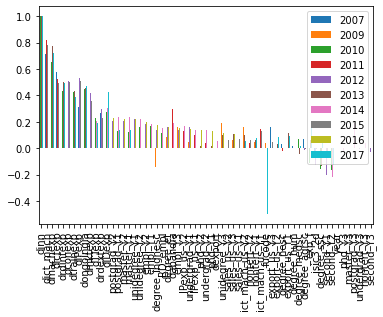

In [34]:
corr_por_ano.plot(kind='bar')

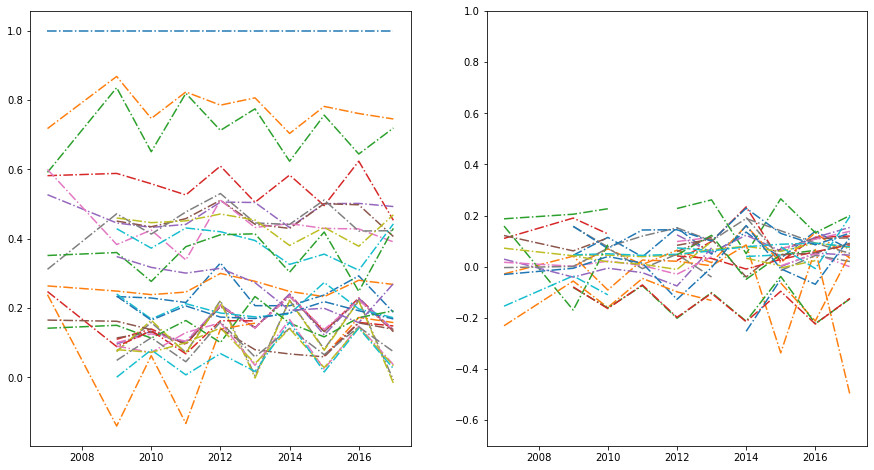

In [27]:
# Comparação dos modelos
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15,8))
halfway = round(len(corr_por_ano.index)/2)

for i in corr_por_ano.index[:halfway]:
    ax1.plot(corr_por_ano.columns,corr_por_ano.loc[i,:], linestyle='dashdot')
    plt.ylim([-0.7, 1])
for i in corr_por_ano.index[halfway:]:
    ax2.plot(corr_por_ano.columns,corr_por_ano.loc[i,:], linestyle='dashdot')
    plt.ylim([-0.7, 1])

plt.show()

In [48]:
corr_por_ano.dropna(inplace=True)

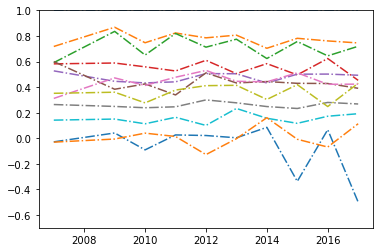

In [49]:
for i in corr_por_ano.index:
    plt.plot(corr_por_ano.columns,corr_por_ano.loc[i,:], linestyle='dashdot')
    plt.ylim([-0.7, 1])
    #plt.show()

Conclusão: pouca alteração nas correlações durante os anos

In [39]:
cuts = []
for i in corr_por_ano.columns:
    binned  = pd.cut(corr_por_ano[i], bins=[-np.inf,-0.8,-0.5,-0.3,0,0.3,0.5,0.8,np.inf], labels=['Muito Forte - Negativa', 'Forte - Negativa', 'Moderada - Negativa', 'Fraca - Negativa', 'Fraca - Positiva', 'Moderada - Positiva', 'Forte - Positiva', 'Muito Forte - Positiva'])
    cuts.append(binned)

In [41]:
corr_por_ano_categ = pd.concat(cuts, axis=1)

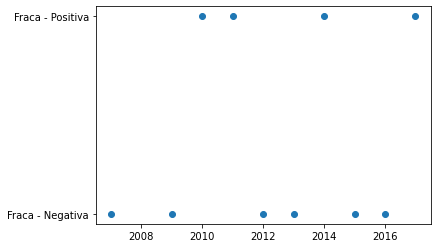

In [54]:
plt.scatter(corr_por_ano_categ.columns,corr_por_ano_categ.loc[i,:])


ValueError: could not convert string to float: 'Moderada - Positiva'

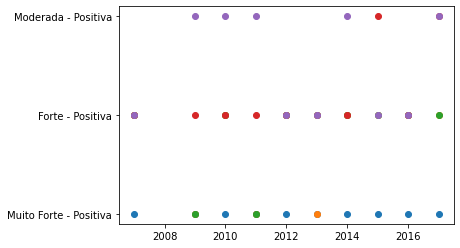

In [56]:
for i in corr_por_ano_categ.index:
    plt.scatter(corr_por_ano_categ.columns,corr_por_ano_categ.loc[i,:])
    #plt.show()